In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

# PHASE 1: SETUP & VARIABLES

data_dir = r"path-to-folder\Minor-project-DL-models\COVID-19_Radiography_Dataset"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 123 

# PHASE 2: DATA SPLITTING & LOADING
print("--- Loading Datasets ---")


train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    label_mode='categorical',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)


val_and_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    label_mode='categorical',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)


val_batches = tf.data.experimental.cardinality(val_and_test_dataset)
validation_dataset = val_and_test_dataset.take(val_batches // 2)
test_dataset = val_and_test_dataset.skip(val_batches // 2)


AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)


--- Loading Datasets ---
Found 21165 files belonging to 4 classes.
Using 14816 files for training.
Found 21165 files belonging to 4 classes.
Using 6349 files for validation.


In [ ]:
# PHASE 3: DATA AUGMENTATION

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomBrightness(factor=0.2),
    keras.layers.RandomContrast(factor=0.2)
], name="medical_augmentation_pipeline")

print("\n--- Data Augmentation Pipeline Ready ---")


# PHASE 4: CLINICALLY ADJUSTED CLASS WEIGHTS
print("\n--- Calculating Class Weights ---")


covid_dir = os.path.join(data_dir, "covid-19")
lung_opacity_dir = os.path.join(data_dir, "lung_opacity")
normal_dir = os.path.join(data_dir, "normal")
pneumonia_dir = os.path.join(data_dir, "pneumonia")


covid_count = len(os.listdir(covid_dir))
lung_opacity_count = len(os.listdir(lung_opacity_dir))
normal_count = len(os.listdir(normal_dir))
pneumonia_count = len(os.listdir(pneumonia_dir))

total_images = covid_count + lung_opacity_count + normal_count + pneumonia_count
num_classes = 4


base_covid = (1 / covid_count) * (total_images / num_classes)
base_opacity = (1 / lung_opacity_count) * (total_images / num_classes)
base_normal = (1 / normal_count) * (total_images / num_classes)
base_pneumonia = (1 / pneumonia_count) * (total_images / num_classes)


class_weights = {
    0: base_covid,
    1: base_opacity,
    2: base_normal,
    3: base_pneumonia
}

print(f"Total Images Processed: {total_images}")
print("Final Class Weights Dictionary:", class_weights)
print("\n✅ PIPELINE COMPLETE. READY FOR MODEL ARCHITECTURE.")


--- Data Augmentation Pipeline Ready ---

--- Calculating Class Weights ---
Total Images Processed: 21165
Final Class Weights Dictionary: {0: 1.4632881637168142, 1: 0.8801147704590818, 2: 0.5191571821036107, 3: 3.934014869888476}

✅ PIPELINE COMPLETE. READY FOR MODEL ARCHITECTURE.


In [ ]:
# PHASE 5: CUSTOM CNN ARCHITECTURE

print("\n--- Building Custom CNN Baseline Model ---")


inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)

x = keras.layers.Rescaling(1./255)(x) 
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

x = keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

x = keras.layers.Dropout(0.25)(x) 
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(128, activation='relu')(x)

x = keras.layers.Dropout(0.25)(x) 

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)


custom_model = keras.Model(inputs, outputs, name="Custom_Medical_CNN")

custom_model.summary()




--- Building Custom CNN Baseline Model ---


Model: "Custom_Medical_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ medical_augmentation_pipeline   │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


def get_callbacks(model_name):
    
    checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    return [checkpoint, early_stopping]

# PHASE 6: COMPILATION & TRAINING
print("\n--- Compiling Model ---")


custom_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')] 
)

print("\n--- Starting Training ---")

custom_callbacks = get_callbacks("Custom_Medical_CNN")
EPOCHS = 30

history_custom = custom_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=custom_callbacks 
)

print("\n✅ CUSTOM MODEL TRAINING COMPLETE AND SAFELY CHECKPOINTED.")


--- Compiling Model ---

--- Starting Training ---
Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.4403 - auc: 0.7153 - loss: 1.1585
Epoch 1: val_auc improved from None to 0.86746, saving model to Custom_Medical_CNN_best.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 307s 655ms/step - accuracy: 0.5055 - auc: 0.7745 - loss: 1.0061 - val_accuracy: 0.6439 - val_auc: 0.8675 - val_loss: 0.8604
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.5849 - auc: 0.8301 - loss: 0.8614
Epoch 2: val_auc improved from 0.86746 to 0.88841, saving model to Custom_Medical_CNN_best.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 323s 697ms/step - accuracy: 0.5780 - auc: 0.8292 - loss: 0.8617 - val_accuracy: 0.6600 - val_auc: 0.8884 - val_loss: 0.7887
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.6098 - auc: 0.8530 - loss: 0.7998
Epoch 3: val_auc did not improve from 0.88841
463/463 ━━━━━━━━━━━━━━━━━━━━ 343s 741ms/step - accuracy: 0.6144 - auc: 0.8556 - loss: 0.7952 - val_


--- Step 1: Overall Testing Metrics ---
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.8497 - auc: 0.9735 - loss: 0.3820
Test Accuracy: 84.97%
Test AUC: 0.9735

--- Step 2: Generating Predictions ---
Predictions generated successfully.

--- Step 3: The Confusion Matrix ---


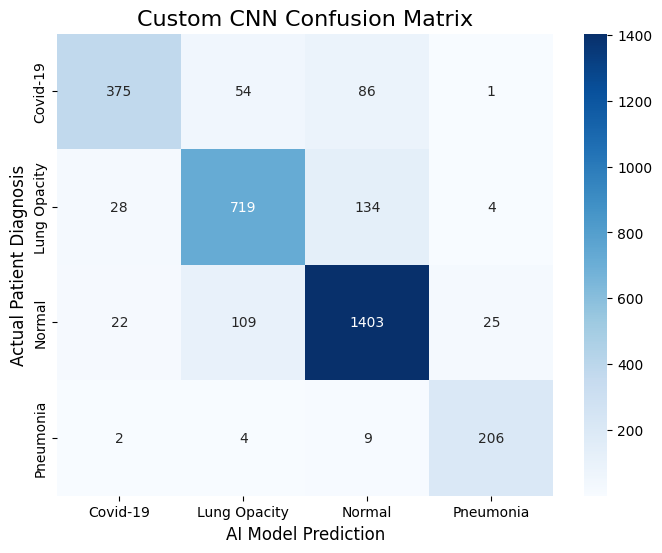


--- Step 4: Classification Report ---
              precision    recall  f1-score   support

    Covid-19       0.88      0.73      0.80       516
Lung Opacity       0.81      0.81      0.81       885
      Normal       0.86      0.90      0.88      1559
   Pneumonia       0.87      0.93      0.90       221

    accuracy                           0.85      3181
   macro avg       0.86      0.84      0.85      3181
weighted avg       0.85      0.85      0.85      3181



In [ ]:
# PHASE 7: EVALUATION & METRICS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- Step 1: Overall Testing Metrics ---")

test_loss, test_accuracy, test_auc = custom_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

print("\n--- Step 2: Generating Predictions ---")

y_true = []
y_pred_probs = []


for images, labels in test_dataset:   
    y_true.extend(np.argmax(labels.numpy(), axis=1))   
    preds = custom_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully.")


# PHASE 8: VISUALIZING THE MISTAKES

print("\n--- Step 3: The Confusion Matrix ---")


class_names = ['Covid-19', 'Lung Opacity', 'Normal', 'Pneumonia']
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Custom CNN Confusion Matrix', fontsize=16)
plt.ylabel('Actual Patient Diagnosis', fontsize=12)
plt.xlabel('AI Model Prediction', fontsize=12)
plt.show()

# PHASE 9: THE CLINICAL REPORT
print("\n--- Step 4: Classification Report ---")
report = classification_report(y_true, y_pred_classes, target_names=class_names)
print(report)

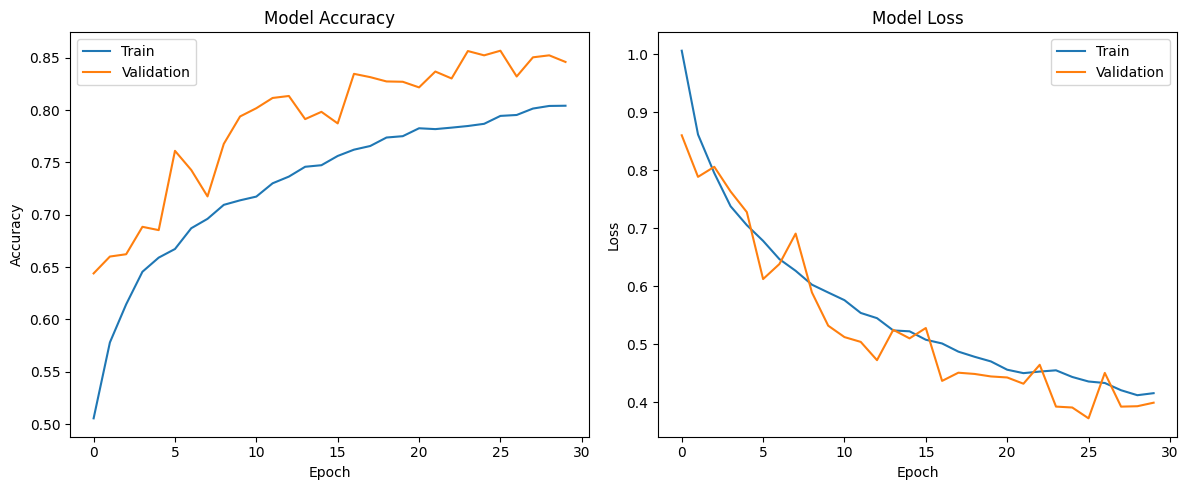

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_custom.history['accuracy'])
plt.plot(history_custom.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(history_custom.history['loss'])
plt.plot(history_custom.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

loaded_model = tf.keras.models.load_model("Custom_Medical_CNN_best.keras")
print("Model loaded successfully!")

img_path = r"C:\Users\siddh\Documents\GitHub\Minor-project-DL-models\COVID-19_Radiography_Dataset\covid-19\COVID-58.png"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 

predictions = loaded_model.predict(img_array)

class_names = ['Covid', 'Lung Opacity', 'Normal', 'Pneumonia']
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

print(f"Diagnosis: {class_names[predicted_class_index]}")
print(f"AI Confidence: {confidence:.2f}%")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Diagnosis: Covid
AI Confidence: 87.44%
